In [69]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

# Load dataset
data = pd.read_csv('data.csv')

# 🔥 FIX: remove empty column
data = data.dropna(axis=1)

print('Shape of the data:', data.shape)
print('First 5 rows of the data:')
print(data.head())
print('\n Missing values in each column:')
print(data.isnull().sum())
 

# last column is the target variable

print("\nClass distribution:\n", data.iloc[:, 1].value_counts())

# Split features and labels
X = data.iloc[:, 2:].values
y = data.iloc[:, 1].values

# Normalize safely
X_min = X.min(axis=0)
X_max = X.max(axis=0)

denominator = X_max - X_min
denominator[denominator == 0] = 1

X = (X - X_min) / denominator

# Encode labels
le = LabelEncoder()
y = le.fit_transform(y)

# Final check
print("Any NaN in X:", np.isnan(X).any())



print(data.columns)
print(data.isnull().sum())

Shape of the data: (569, 32)
First 5 rows of the data:
         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ... 

In [70]:
# Splitting Data into Training and Testing sets
# 80% for training and 20% for testing


split = int(0.8 * len(X))

X_train = X[:split]
X_val = X[split:]

y_train = y[:split]
y_val = y[split:]


In [71]:
# ============================
# Building Custom ANN Model
# ============================

input_size = X.shape[1]
hidden1 = 32
hidden2 = 16
output_size = 1

np.random.seed(42)

# He Initialization (important for ReLU)
W1 = np.random.randn(input_size, hidden1) * np.sqrt(2 / input_size)
b1 = np.zeros((1, hidden1))

W2 = np.random.randn(hidden1, hidden2) * np.sqrt(2 / hidden1)
b2 = np.zeros((1, hidden2))

W3 = np.random.randn(hidden2, output_size) * np.sqrt(2 / hidden2)
b3 = np.zeros((1, output_size))


# Activation Functions
def relu(x):
    return np.maximum(0, x)

def relu_derivative(x):
    return (x > 0).astype(float)

def sigmoid(x):
    x = np.clip(x, -500, 500)
    return 1 / (1 + np.exp(-x))


# Dropout
def dropout(A, rate=0.2):
    mask = (np.random.rand(*A.shape) > rate).astype(float)
    return A * mask, mask


# Forward Propagation
def forward(X, training=True):
    global Z1, A1, Z2, A2, Z3, A3, D1
    
    Z1 = np.dot(X, W1) + b1
    A1 = relu(Z1)
    
    if training:
        A1, D1 = dropout(A1, 0.2)
    else:
        D1 = np.ones_like(A1)
    
    Z2 = np.dot(A1, W2) + b2
    A2 = relu(Z2)
    
    Z3 = np.dot(A2, W3) + b3
    A3 = sigmoid(Z3)
    
    return A3


# Loss Function (Binary Cross Entropy)
def compute_loss(y, y_pred):
    m = len(y)
    y = y.reshape(-1, 1)
    
    y_pred = np.clip(y_pred, 1e-8, 1 - 1e-8)
    
    loss = - (1/m) * np.sum(
        y*np.log(y_pred) + 
        (1-y)*np.log(1 - y_pred)
    )
    return loss


# Backpropagation
learning_rate = 0.01

def backward(X, y, y_pred):
    global W1, W2, W3, b1, b2, b3
    
    m = X.shape[0]
    
    dZ3 = y_pred - y.reshape(-1,1)
    dW3 = (1/m) * np.dot(A2.T, dZ3)
    db3 = (1/m) * np.sum(dZ3, axis=0, keepdims=True)
    
    dA2 = np.dot(dZ3, W3.T)
    dZ2 = dA2 * relu_derivative(Z2)
    dW2 = (1/m) * np.dot(A1.T, dZ2)
    db2 = (1/m) * np.sum(dZ2, axis=0, keepdims=True)
    
    dA1 = np.dot(dZ2, W2.T)
    dA1 = dA1 * D1
    
    dZ1 = dA1 * relu_derivative(Z1)
    dW1 = (1/m) * np.dot(X.T, dZ1)
    db1 = (1/m) * np.sum(dZ1, axis=0, keepdims=True)
    
    # Update weights
    W1 -= learning_rate * dW1
    W2 -= learning_rate * dW2
    W3 -= learning_rate * dW3
    
    b1 -= learning_rate * db1
    b2 -= learning_rate * db2
    b3 -= learning_rate * db3

In [74]:
# ============================
# Training Model
# ============================

epochs = 300

train_loss = []
val_loss = []

for epoch in range(epochs):
    
    y_pred = forward(X_train, training=True)
    loss = compute_loss(y_train, y_pred)
    
    backward(X_train, y_train, y_pred)
    
    val_pred = forward(X_val, training=False)
    v_loss = compute_loss(y_val, val_pred)
    
    train_loss.append(loss)
    val_loss.append(v_loss)
    
    train_acc = np.mean((y_pred > 0.5).astype(int).flatten() == y_train)
    val_acc = np.mean((val_pred > 0.5).astype(int).flatten() == y_val)
    
    print(f"Epoch {epoch+1} → Loss: {loss:.4f}, Val Loss: {v_loss:.4f}, Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}")

Epoch 1 → Loss: 0.5416, Val Loss: 0.5330, Train Acc: 0.8725, Val Acc: 0.9123
Epoch 2 → Loss: 0.5360, Val Loss: 0.5325, Train Acc: 0.8967, Val Acc: 0.9123
Epoch 3 → Loss: 0.5307, Val Loss: 0.5319, Train Acc: 0.8901, Val Acc: 0.9123
Epoch 4 → Loss: 0.5335, Val Loss: 0.5314, Train Acc: 0.8901, Val Acc: 0.9123
Epoch 5 → Loss: 0.5381, Val Loss: 0.5309, Train Acc: 0.8747, Val Acc: 0.9123
Epoch 6 → Loss: 0.5356, Val Loss: 0.5304, Train Acc: 0.8813, Val Acc: 0.9123
Epoch 7 → Loss: 0.5281, Val Loss: 0.5298, Train Acc: 0.9033, Val Acc: 0.9123
Epoch 8 → Loss: 0.5293, Val Loss: 0.5293, Train Acc: 0.8791, Val Acc: 0.9123
Epoch 9 → Loss: 0.5284, Val Loss: 0.5287, Train Acc: 0.8967, Val Acc: 0.9123
Epoch 10 → Loss: 0.5359, Val Loss: 0.5282, Train Acc: 0.8725, Val Acc: 0.9123
Epoch 11 → Loss: 0.5318, Val Loss: 0.5276, Train Acc: 0.8659, Val Acc: 0.9123
Epoch 12 → Loss: 0.5365, Val Loss: 0.5272, Train Acc: 0.8637, Val Acc: 0.9123
Epoch 13 → Loss: 0.5290, Val Loss: 0.5268, Train Acc: 0.8769, Val Acc: 0.

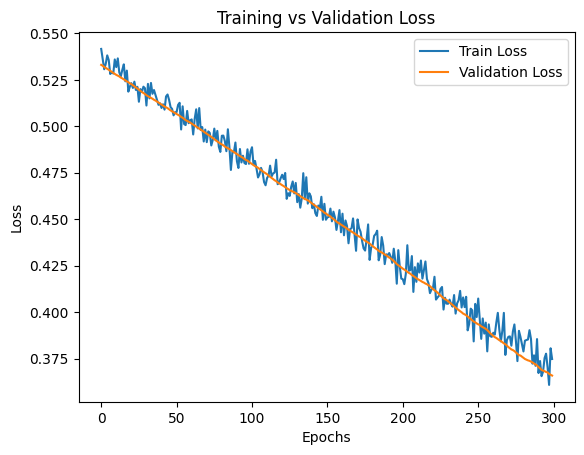

In [75]:
import matplotlib.pyplot as plt

plt.plot(train_loss, label="Train Loss")
plt.plot(val_loss, label="Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

In [76]:
# Predictions
y_pred = forward(X_val, training=False)
y_pred = (y_pred > 0.5).astype(int).flatten()

# Confusion Matrix (Custom)
def confusion_matrix(y_true, y_pred):
    TP = TN = FP = FN = 0
    
    for i in range(len(y_true)):
        if y_true[i] == 1 and y_pred[i] == 1:
            TP += 1
        elif y_true[i] == 0 and y_pred[i] == 0:
            TN += 1
        elif y_true[i] == 0 and y_pred[i] == 1:
            FP += 1
        elif y_true[i] == 1 and y_pred[i] == 0:
            FN += 1
    
    return TP, TN, FP, FN

TP, TN, FP, FN = confusion_matrix(y_val, y_pred)

print("TP:", TP, "TN:", TN, "FP:", FP, "FN:", FN)


# Metrics
accuracy = (TP + TN) / (TP + TN + FP + FN)
precision = TP / (TP + FP + 1e-8)
recall = TP / (TP + FN + 1e-8)
f1 = 2 * (precision * recall) / (precision + recall + 1e-8)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

TP: 26 TN: 80 FP: 8 FN: 0
Accuracy: 0.9298245614035088
Precision: 0.7647058821280277
Recall: 0.9999999996153845
F1 Score: 0.8666666614666667
